### Bundles Engine Solution


The solution uses the existing Dynamic Pricing Algorithm unchanged, predicts the business popularity of a bundle from historical bundle data, uses a Genetic Algorithm to search for better bundle structures under telecom business constraints, subtracts cannibalization risk from the objective, and finally uses an LLM only for naming and presentation.

1. Building the popularity model that predict popularity score (revenue and revenue contribution) for a give bundle features.

2. building cannibalization model.

3. pricing based on our dynamic pricing algorithm

4. building Genetic algorithm to generate new bundle structures with objective to maximize the popularity score and minimize the cannibalization under the operator's constraints.

5. using LLM to name the generated bundles.


In [56]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit

### Popularity Model

predict Popularity score based on bundle features without its name.

In [15]:
DATASET_FOLDER: str = r"..\..\datasets"
WEEKLY_BUNDLES_DATA_PATH: str = rf"{DATASET_FOLDER}\weekly_base_bundles_info_202501_202510.csv"


data = pd.read_csv(WEEKLY_BUNDLES_DATA_PATH) 
print(data.shape)
data.head(10)

(42377, 15)


,week_number,year_number,bundle_id,bundle_name,bundle_type,validity,price,usage_type,configured_volume,service_class_category,total_duration,total_rev,total_subscriptions,total_sessions,unique_users
0,1,2025,37076,Forfait 1.6Go 30 jours@4000F,BUNDLE_DATA,30 Day(s),4000,CHARGED,1.61,PREPAID,0.0,36000.00,9,10,9
1,1,2025,50134,Forfait appels RCA 2 mins 30 jours@690F,INT_BUNDLE_VOICE,30 Day(s),690,CHARGED,2MIN,PREPAID,0.0,3450.00,5,5,5
2,1,2025,50129,Forfait appels Nigeria 2 mins 30 jours@200F,INT_BUNDLE_VOICE,30 Day(s),200,CHARGED,2MIN,PREPAID,0.0,400.00,2,2,1
3,1,2025,35070,Forfait 1 jour 170MB@215F,BUNDLE_DATA,1 Day(s),215,CHARGED,170,PREPAID,0.0,124060.00,577,584,340
4,1,2025,36667,NDAKO BOX ILLIMITE@50050F,BUNDLE_DATA,30 Day(s),50050,CHARGED,Unlimited,PREPAID,0.0,200200.00,4,4,4
5,1,2025,50191,Int Bundle ROW 10min 30jours a 1500F,INT_BUNDLE_VOICE,30 Day(s),1500,CHARGED,10MIN,PREPAID,0.0,37500.00,25,25,24
6,1,2025,50214,Forfait appels Guinee Conakry 2 mins 30 jours@...,INT_BUNDLE_VOICE,30 Day(s),590,CHARGED,2MIN,PREPAID,0.0,56640.00,96,97,49
7,1,2025,80069,Ndeko_11Mins 1 jour@185F,BUNDLE_VOICE,1 Day(s),185,CHARGED,11min,PREPAID,0.0,17161358.36,98080,98523,65542
8,1,2025,SMSPK100,SMS Bundle 3 Days@122F,BUNDLE_SMS,3 Day(s),122,CHARGED,NaN,PREPAID,0.0,10018029.99,82115,82115,20643
9,1,2025,36279,Promo Back2School 250MB 2 Days @50F,BUNDLE_DATA,2 Day(s),50,CHARGED,250MB,PREPAID,0.0,10850.00,217,220,216


In [17]:
data = data[~data['configured_volume'].isna()]

In [20]:
# Extract Configured Volumes 'configured_volume'
def extract_conf_volume_values(volume_str):
    """
    Extract MB, minutes, and SMS from configured_volume string.
    Handles: GB (→ MB), MB, Minutes, SMS, commas, combinations, addition formats, etc.
    """
    if pd.isna(volume_str) or volume_str is None:
        return {'mb': None, 'min': None, 'sms': None}
    
    original_str = str(volume_str)
    if original_str.lower() in ['unlimited', 'illimité', 'illimite']:
        return {'mb': None, 'min': None, 'sms': None}
    
    volume_str = original_str.replace(',', '.')
    volume_str_upper = volume_str.upper()
    
    mb_value = None
    min_value = None
    sms_value = None
    
    # extract GB and convert to MB
    gb_pattern = r'(\d+(?:\.\d+)?)\s*G(?:B)?\b'
    gb_matches = re.findall(gb_pattern, volume_str_upper)
    if gb_matches:
        mb_value = sum(float(gb) for gb in gb_matches) * 1024
    
    # extract MB
    mb_pattern = r'(\d+(?:\.\d+)?)\s*MB\b'
    mb_matches = re.findall(mb_pattern, volume_str_upper)
    if mb_matches:
        total_mb = sum(float(mb) for mb in mb_matches)
        mb_value = total_mb if mb_value is None else mb_value + total_mb
    
    # extract minutes
    min_pattern = r'(\d+(?:\.\d+)?)\s*MINS?\b'
    min_matches = re.findall(min_pattern, volume_str_upper)
    add_pattern_min = r'(\d+(?:\.\d+)?)\s*\+\s*(\d+(?:\.\d+)?)\s*MINS?\b'
    add_match_min = re.search(add_pattern_min, volume_str_upper)
    
    if add_match_min:
        min_value = float(add_match_min.group(1)) + float(add_match_min.group(2))
    elif min_matches:
        min_value = sum(float(m) for m in min_matches)
    
    # extract SMS
    sms_pattern = r'(\d+(?:\.\d+)?)\s*SMS\b'
    sms_matches = re.findall(sms_pattern, volume_str_upper)
    if sms_matches:
        sms_value = sum(float(sms) for sms in sms_matches)
    
    # handle "/" formats like "200/40 mins"
    slash_pattern = r'(\d+(?:\.\d+)?)\s*/\s*(\d+(?:\.\d+)?)'
    slash_match = re.search(slash_pattern, volume_str)
    if slash_match and 'MIN' in volume_str_upper:
        if min_value is None:
            min_value = float(slash_match.group(2))
        if mb_value is None:
            mb_value = float(slash_match.group(1))
    
    # handle seconds
    sec_pattern = r'(\d+(?:\.\d+)?)\s*SEC\b'
    sec_matches = re.findall(sec_pattern, volume_str_upper)
    if sec_matches:
        sec_as_min = sum(float(sec) for sec in sec_matches) / 60.0
        min_value = sec_as_min if min_value is None else min_value + sec_as_min
    
    return {'mb': mb_value, 'min': min_value, 'sms': sms_value}


volume_extracted = data['configured_volume'].apply(extract_conf_volume_values)
data['configured_volume_mb'] = volume_extracted.apply(lambda x: x['mb'] if x['mb'] is not None else 0.0)
data['configured_volume_min'] = volume_extracted.apply(lambda x: x['min'] if x['min'] is not None else 0.0)
data['configured_volume_sms'] = volume_extracted.apply(lambda x: x['sms'] if x['sms'] is not None else 0.0)
data.drop(columns=['configured_volume'], inplace=True)

In [21]:
def clean_price(val) -> float:
        if pd.isna(val):
            return None
        val = str(val).replace("F", "").replace(",", "")
        try:
            return float(val)
        except:
            return None
        
data["price"] = data["price"].apply(clean_price)

In [23]:
data['clean_validity'] = np.where(
    data['validity'].str.strip().str.lower().isin(['null', '']) | data['validity'].isna(),
    None,
    data['validity']
        .str.strip()
        .str.lower()
        .str.replace(r'\(s\)', '', regex=True)         # remove (s)
        .str.replace(r'\bday\b', 'days', regex=True)  # day → days
        .str.replace(r'\bmonth\b', 'months', regex=True)  # month → months
)
data.drop(columns=['validity'], inplace=True)
data = data.rename(columns={"clean_validity": "validity"})


In [24]:
def parse_validity_to_hours(val):
    """
    Convert variants like '7 days', '4 hours', '3 months', '1  days', None -> hours (float)
    Uses 30 days per month convention for telecom.
    Returns np.nan if cannot parse.
    """
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float)):
        # unexpected numeric — treat as days
        return float(val) * 24.0
    s = str(val).strip().lower()
    # correct double spaces
    s = re.sub(r"\s+", " ", s)
    # find number
    m = re.match(r"^(\d+(\.\d+)?)\s*(day|days|hour|hours|month|months)?", s)
    if not m:
        return np.nan
    num = float(m.group(1))
    unit = m.group(3) or "days"
    if "hour" in unit:
        return num
    if "day" in unit:
        return num * 24.0
    if "month" in unit:
        return num * 30.0 * 24.0
    # fallback assume days
    return num * 24.0

data['validity_hours'] = data['validity'].apply(parse_validity_to_hours)

In [25]:
data = data[~data["bundle_name"].str.contains("DIY", case=False, na=False)]

In [27]:
data.drop(columns=['total_duration'], inplace=True)
data.dropna(subset=['bundle_name'], inplace=True)

In [29]:
data['validity'] = data['validity'].fillna('NO_VALIDITY')
data['validity_hours'] = data['validity_hours'].fillna(0)

In [30]:
def extract_price(text):
    if pd.isna(text):
        return None
    match = re.search(r'@(\d+)\s*F', str(text))
    if match:
        return float(match.group(1))
    return None

# try to extract price from bundle_name for all rows with missing price
mask_missing_price = data['price'].isna()
data.loc[mask_missing_price, 'price_extracted'] = \
    data.loc[mask_missing_price, 'bundle_name'].apply(extract_price)

# fill price where extraction was successful
data['price'] = data['price'].fillna(data['price_extracted'])


# 4. FREE bundles (@F)
free_mask = data['bundle_name'].str.contains('@F', na=False)
data.loc[free_mask, 'price'] = 0

# STAFF bundles
staff_mask = data['bundle_name'].str.contains('STAFF', na=False, case=False)
data.loc[staff_mask, 'price'] = 0

# VAS services and system events
system_names = ['SDP VAS', 'MTN ME2U', 'MTN Xtratime', 
                'MTN Call Me Back', 'MTN Tv']

system_mask = data['bundle_name'].isin(system_names)
data.loc[system_mask, 'price'] = 0

# Anything still missing → truly unknown, set to zero but mark category
still_missing = data['price'].isna()
data.loc[still_missing, 'price'] = 0

data.drop(columns=['price_extracted'], inplace=True)

In [31]:
def week_to_season(iso_week):
    if 1 <= iso_week <= 13:
        return "winter"
    elif 14 <= iso_week <= 26:
        return "spring"
    elif 27 <= iso_week <= 39:
        return "summer"
    else:
        return "autumn"

data["season"] = data["week_number"].apply(week_to_season)

In [32]:
# Add revenue contribution for each bundle in each week.
rev_by_iso_week = data.groupby("week_number")["total_rev"].sum()
data["week_total_rev"] = data["week_number"].map(rev_by_iso_week)
data["rev_contribution"] = data["total_rev"] / data["week_total_rev"]
data["rev_contribution_pct"] = data["rev_contribution"] * 100
data.drop(columns=['week_total_rev'], inplace=True)

In [36]:
data = data[~(data['total_rev'] <= 0.0)]
data = data[~(data['usage_type'] == 'FREE')]

In [38]:
def is_illimite(bundle_name: str) -> int:
    return 1 if "illimite" in bundle_name.lower() else 0

data['is_illimite'] = data['bundle_name'].apply(is_illimite)

In [39]:
data.head(10)

,week_number,year_number,bundle_id,bundle_name,bundle_type,price,usage_type,service_class_category,total_rev,total_subscriptions,...,unique_users,configured_volume_mb,configured_volume_min,configured_volume_sms,validity,validity_hours,season,rev_contribution,rev_contribution_pct,is_illimite
0,1,2025,37076,Forfait 1.6Go 30 jours@4000F,BUNDLE_DATA,4000.0,CHARGED,PREPAID,36000.00,9,...,9,0.0,0.0,0.0,30 days,720.0,winter,2.793816e-05,0.002794,0
1,1,2025,50134,Forfait appels RCA 2 mins 30 jours@690F,INT_BUNDLE_VOICE,690.0,CHARGED,PREPAID,3450.00,5,...,5,0.0,2.0,0.0,30 days,720.0,winter,2.677407e-06,0.000268,0
2,1,2025,50129,Forfait appels Nigeria 2 mins 30 jours@200F,INT_BUNDLE_VOICE,200.0,CHARGED,PREPAID,400.00,2,...,1,0.0,2.0,0.0,30 days,720.0,winter,3.104240e-07,0.000031,0
3,1,2025,35070,Forfait 1 jour 170MB@215F,BUNDLE_DATA,215.0,CHARGED,PREPAID,124060.00,577,...,340,0.0,0.0,0.0,1 days,24.0,winter,9.627801e-05,0.009628,0
4,1,2025,36667,NDAKO BOX ILLIMITE@50050F,BUNDLE_DATA,50050.0,CHARGED,PREPAID,200200.00,4,...,4,0.0,0.0,0.0,30 days,720.0,winter,1.553672e-04,0.015537,1
5,1,2025,50191,Int Bundle ROW 10min 30jours a 1500F,INT_BUNDLE_VOICE,1500.0,CHARGED,PREPAID,37500.00,25,...,24,0.0,10.0,0.0,30 days,720.0,winter,2.910225e-05,0.002910,0
6,1,2025,50214,Forfait appels Guinee Conakry 2 mins 30 jours@...,INT_BUNDLE_VOICE,590.0,CHARGED,PREPAID,56640.00,96,...,49,0.0,2.0,0.0,30 days,720.0,winter,4.395604e-05,0.004396,0
7,1,2025,80069,Ndeko_11Mins 1 jour@185F,BUNDLE_VOICE,185.0,CHARGED,PREPAID,17161358.36,98080,...,65542,0.0,11.0,0.0,1 days,24.0,winter,1.331824e-02,1.331824,0
9,1,2025,36279,Promo Back2School 250MB 2 Days @50F,BUNDLE_DATA,50.0,CHARGED,PREPAID,10850.00,217,...,216,250.0,0.0,0.0,2 days,48.0,winter,8.420251e-06,0.000842,0
11,1,2025,36602,Maxinet 3 Days 9H@425F,BUNDLE_DATA,425.0,CHARGED,PREPAID,1609475.00,3787,...,2336,0.0,0.0,0.0,3 days,72.0,winter,1.249049e-03,0.124905,0


In [41]:
def norm(col, eps=1e-9):
    col = np.log1p(col)  # compress heavy tails
    return (col - col.min()) / (col.max() - col.min() + eps)


def compute_popularity(df, eps=1e-9):
    df = df.copy()

    df["R_norm"]   = norm(df["total_rev"])
    df["U_norm"]   = norm(df["unique_users"])
    df["rev_contribution_norm"] = norm(df["rev_contribution_pct"])

    # populatiry func
    β, γ,  δ = 0.50, 0.25, 0.25
 
    df["popularity_score"] = (
        β * df["R_norm"] +
        γ * df["U_norm"] +
        δ * df["rev_contribution_norm"]
    )
    print("populatiry func computed")

    return df

data_pop = compute_popularity(data)

populatiry func computed


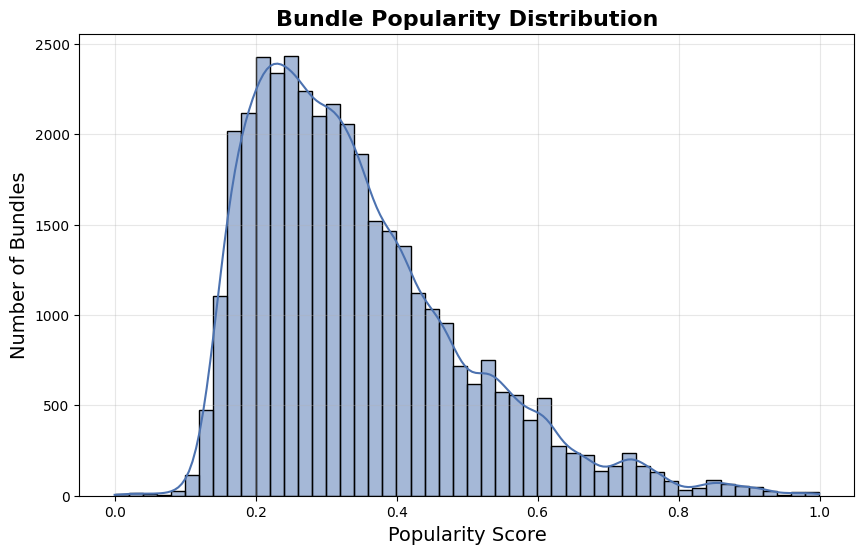

In [49]:
plt.figure(figsize=(10,6))
sns.histplot(data_pop['popularity_score'], bins=50, kde=True, color="#4C72B0", edgecolor='black')
plt.title("Bundle Popularity Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Popularity Score", fontsize=14)
plt.ylabel("Number of Bundles", fontsize=14)
plt.grid(alpha=0.3)
plt.show()

In [51]:
data.loc[:, 'popularity'] = data_pop['popularity_score'].values
del data_pop

In [52]:
data.head(10)

,week_number,year_number,bundle_id,bundle_name,bundle_type,price,usage_type,service_class_category,total_rev,total_subscriptions,...,configured_volume_mb,configured_volume_min,configured_volume_sms,validity,validity_hours,season,rev_contribution,rev_contribution_pct,is_illimite,popularity
0,1,2025,37076,Forfait 1.6Go 30 jours@4000F,BUNDLE_DATA,4000.0,CHARGED,PREPAID,36000.00,9,...,0.0,0.0,0.0,30 days,720.0,winter,2.793816e-05,0.002794,0,0.307323
1,1,2025,50134,Forfait appels RCA 2 mins 30 jours@690F,INT_BUNDLE_VOICE,690.0,CHARGED,PREPAID,3450.00,5,...,0.0,2.0,0.0,30 days,720.0,winter,2.677407e-06,0.000268,0,0.234772
2,1,2025,50129,Forfait appels Nigeria 2 mins 30 jours@200F,INT_BUNDLE_VOICE,200.0,CHARGED,PREPAID,400.00,2,...,0.0,2.0,0.0,30 days,720.0,winter,3.104240e-07,0.000031,0,0.155463
3,1,2025,35070,Forfait 1 jour 170MB@215F,BUNDLE_DATA,215.0,CHARGED,PREPAID,124060.00,577,...,0.0,0.0,0.0,1 days,24.0,winter,9.627801e-05,0.009628,0,0.413100
4,1,2025,36667,NDAKO BOX ILLIMITE@50050F,BUNDLE_DATA,50050.0,CHARGED,PREPAID,200200.00,4,...,0.0,0.0,0.0,30 days,720.0,winter,1.553672e-04,0.015537,1,0.339628
5,1,2025,50191,Int Bundle ROW 10min 30jours a 1500F,INT_BUNDLE_VOICE,1500.0,CHARGED,PREPAID,37500.00,25,...,0.0,10.0,0.0,30 days,720.0,winter,2.910225e-05,0.002910,0,0.327224
6,1,2025,50214,Forfait appels Guinee Conakry 2 mins 30 jours@...,INT_BUNDLE_VOICE,590.0,CHARGED,PREPAID,56640.00,96,...,0.0,2.0,0.0,30 days,720.0,winter,4.395604e-05,0.004396,0,0.352477
7,1,2025,80069,Ndeko_11Mins 1 jour@185F,BUNDLE_VOICE,185.0,CHARGED,PREPAID,17161358.36,98080,...,0.0,11.0,0.0,1 days,24.0,winter,1.331824e-02,1.331824,0,0.738287
9,1,2025,36279,Promo Back2School 250MB 2 Days @50F,BUNDLE_DATA,50.0,CHARGED,PREPAID,10850.00,217,...,250.0,0.0,0.0,2 days,48.0,winter,8.420251e-06,0.000842,0,0.338694
11,1,2025,36602,Maxinet 3 Days 9H@425F,BUNDLE_DATA,425.0,CHARGED,PREPAID,1609475.00,3787,...,0.0,0.0,0.0,3 days,72.0,winter,1.249049e-03,0.124905,0,0.531439


In [ ]:
p40 = data['popularity'].quantile(0.40)
p80 = data['popularity'].quantile(0.80)
data['popularity_category'] = pd.cut(
    data['popularity'],
    bins=[-float('inf'), p40, p80, float('inf')],
    labels=["Unpopular", "Popular", "Very Popular"],
    include_lowest=True
)

def popularity_category(score):
    if score >= p80:
        return "Very Popular"     # top 20%
    elif score >= p40:
        return "Popular"          # middle 40%
    else:
        return "Unpopular"        # bottom 40%

data['popularity_category'] = data['popularity'].apply(popularity_category)
print(data['popularity_category'].value_counts())

popularity_category
Popular         14902
Unpopular       14902
Very Popular     7451
Name: count, dtype: int64


In [54]:
import plotly.express as px

fig = px.scatter_3d(
    data,
    x='unique_users',
    y='rev_contribution_pct',
    z='popularity',
    color='unique_users',
    size='unique_users',
    hover_name='bundle_name'
)

fig.show()

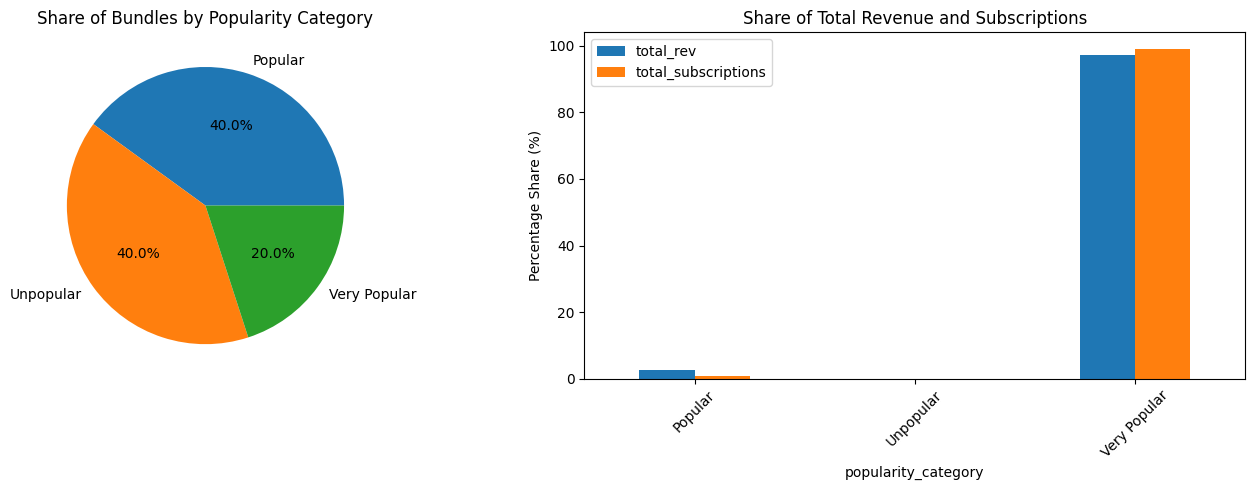

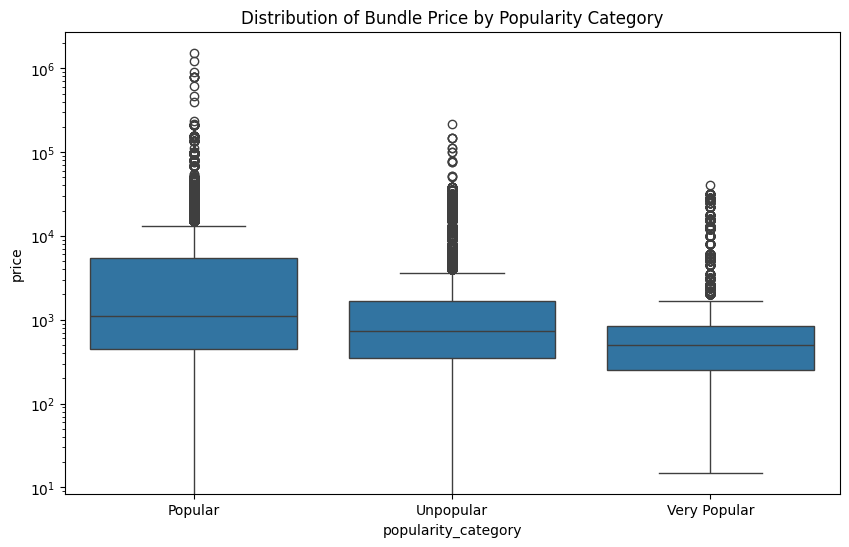

In [55]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

data['popularity_category'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax1, title='Share of Bundles by Popularity Category')
ax1.set_ylabel('')

summary_df = data.groupby('popularity_category').agg({
    'total_rev': 'sum',
    'total_subscriptions': 'sum'
}).apply(lambda x: 100 * x / x.sum()) 

summary_df.plot.bar(ax=ax2, title='Share of Total Revenue and Subscriptions')
ax2.set_ylabel('Percentage Share (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='popularity_category', y='price')
plt.yscale('log') 
plt.title('Distribution of Bundle Price by Popularity Category')
plt.show()

* Building regression model. we will consider only the bundle features without bundle-name and embedding.

In [97]:
def prepare_bundle_training_data(df, target_col="popularity"):
    """
    - the extraction from bundle_name is used only as a fallback when the 
        structured input value is missing or 0, and otherwise the original structured
        value is kept.
    """
    data = df.copy()

    # Basic cleanup
    data.columns = [c.strip() for c in data.columns]
    data["bundle_name"] = data["bundle_name"].fillna("").astype(str)

    numeric_cols = [
        "week_number", "year_number", "price",
        "configured_volume_mb", "configured_volume_min", "configured_volume_sms",
        "validity_hours", "is_illimite"
    ]
    for c in numeric_cols:
        if c in data.columns:
            data[c] = pd.to_numeric(data[c], errors="coerce")

    # keep only rows with target
    data = data[data[target_col].notna()].copy()


    # Parse bundle_name
    def parse_bundle_name(name: str):
        s = str(name).lower().strip().replace(",", ".")
        out = {
            "parsed_volume_mb": np.nan,
            "parsed_volume_min": np.nan,
            "parsed_volume_sms": np.nan,
            "parsed_validity_hours": np.nan,
            "parsed_speed_mbps": np.nan,
            "name_has_data": 0,
            "name_has_voice": 0,
            "name_has_sms": 0,
            "name_has_unlimited": 0,
            "name_has_speed": 0,
            "name_has_social": 0,
            "name_has_roaming": 0,
        }

        # unlimited flags
        if re.search(r"\b(illimite|illimité|unlimited|illimix)\b", s):
            out["name_has_unlimited"] = 1

        # social / app flags
        if re.search(r"\b(whatsapp|tiktok|facebook|youtube|instagram|social)\b", s):
            out["name_has_social"] = 1

        # roaming flags
        if re.search(r"\b(roaming|hadj|voyage|travel)\b", s):
            out["name_has_roaming"] = 1

        # speed parsing: Mbps / Kbps
        m = re.search(r"(\d+(?:\.\d+)?)\s*(mbps|kbps)\b", s)
        if m:
            val = float(m.group(1))
            unit = m.group(2)
            out["parsed_speed_mbps"] = val if unit == "mbps" else val / 1000.0
            out["name_has_speed"] = 1

        # data parsing: GB/Go/Giga/MB/Mb
        data_matches = re.findall(r"(\d+(?:\.\d+)?)\s*(go|gb|giga|g|mb|mo)\b", s)
        if data_matches:
            # take the largest parsed volume if multiple are present
            mb_vals = []
            for val, unit in data_matches:
                val = float(val)
                unit = unit.lower()
                if unit in {"go", "gb", "giga", "g"}:
                    mb_vals.append(val * 1024.0)
                elif unit in {"mb", "mo"}:
                    mb_vals.append(val)
            if mb_vals:
                out["parsed_volume_mb"] = max(mb_vals)
                out["name_has_data"] = 1

        # voice parsing
        m = re.search(r"(\d+(?:\.\d+)?)\s*(min|mins|minute|minutes)\b", s)
        if m:
            out["parsed_volume_min"] = float(m.group(1))
            out["name_has_voice"] = 1

        # SMS parsing
        m = re.search(r"(\d+(?:\.\d+)?)\s*(sms)\b", s)
        if m:
            out["parsed_volume_sms"] = float(m.group(1))
            out["name_has_sms"] = 1

        # validity parsing
        # examples: 1 jour, 30 jours, 3 days, 6 mois, 9H
        m = re.search(r"(\d+(?:\.\d+)?)\s*(jour|jours|day|days|j)\b", s)
        if m:
            out["parsed_validity_hours"] = float(m.group(1)) * 24.0

        m = re.search(r"(\d+(?:\.\d+)?)\s*(mois|month|months)\b", s)
        if m:
            out["parsed_validity_hours"] = float(m.group(1)) * 30.0 * 24.0

        # only use hour parsing if day/month not already parsed
        if pd.isna(out["parsed_validity_hours"]):
            m = re.search(r"(\d+(?:\.\d+)?)\s*(h|hr|hrs|hour|hours)\b", s)
            if m:
                out["parsed_validity_hours"] = float(m.group(1))

        return out

    parsed = data["bundle_name"].apply(parse_bundle_name).apply(pd.Series)
    data = pd.concat([data, parsed], axis=1)


    # Final corrected structural values
    def choose_value(configured, parsed):
        if pd.notna(configured) and configured > 0:
            return configured, "configured"
        if pd.notna(parsed) and parsed > 0:
            return parsed, "parsed_name"
        return 0.0, "zero_or_unknown"

    mb_vals = data.apply(lambda r: choose_value(r.get("configured_volume_mb", np.nan), r["parsed_volume_mb"]), axis=1)
    min_vals = data.apply(lambda r: choose_value(r.get("configured_volume_min", np.nan), r["parsed_volume_min"]), axis=1)
    sms_vals = data.apply(lambda r: choose_value(r.get("configured_volume_sms", np.nan), r["parsed_volume_sms"]), axis=1)
    val_vals = data.apply(lambda r: choose_value(r.get("validity_hours", np.nan), r["parsed_validity_hours"]), axis=1)

    data["volume_mb"] = [x[0] for x in mb_vals]
    data["volume_min"] = [x[0] for x in min_vals]
    data["volume_sms"] = [x[0] for x in sms_vals]
    data["validity_hours"] = [x[0] for x in val_vals]

    data["mb_value_source"] = [x[1] for x in mb_vals]
    data["min_value_source"] = [x[1] for x in min_vals]
    data["sms_value_source"] = [x[1] for x in sms_vals]
    data["validity_value_source"] = [x[1] for x in val_vals]


    #  Special bundle flags
    data["is_unlimited_bundle"] = (
        (data["is_illimite"].fillna(0).astype(int) == 1) |
        (data["name_has_unlimited"] == 1)
    ).astype(int)

    data["is_speed_based_bundle"] = (data["name_has_speed"] == 1).astype(int)
    data["speed_mbps"] = data["parsed_speed_mbps"].fillna(0)

    # if speed bundle or unlimited bundle and quota is zero, keep zero but mark as valid special structure
    data["has_data"] = (data["volume_mb"] > 0).astype(int)
    data["has_voice"] = (data["volume_min"] > 0).astype(int)
    data["has_sms"] = (data["volume_sms"] > 0).astype(int)

    data["is_data_only"] = ((data["has_data"] == 1) & (data["has_voice"] == 0) & (data["has_sms"] == 0)).astype(int)
    data["is_voice_only"] = ((data["has_data"] == 0) & (data["has_voice"] == 1) & (data["has_sms"] == 0)).astype(int)
    data["is_sms_only"] = ((data["has_data"] == 0) & (data["has_voice"] == 0) & (data["has_sms"] == 1)).astype(int)
    data["is_combo_bundle"] = ((data[["has_data", "has_voice", "has_sms"]].sum(axis=1)) >= 2).astype(int)


    data["validity_days"] = data["validity_hours"] / 24.0
    data["validity_days"] = data["validity_days"].replace([np.inf, -np.inf], np.nan).fillna(0)

    data["log_price"] = np.log1p(data["price"].clip(lower=0))
    data["log_mb"] = np.log1p(data["volume_mb"].clip(lower=0))
    data["log_min"] = np.log1p(data["volume_min"].clip(lower=0))
    data["log_sms"] = np.log1p(data["volume_sms"].clip(lower=0))
    data["log_validity_hours"] = np.log1p(data["validity_hours"].clip(lower=0))

    # validity bucket
    data["validity_bucket"] = np.select(
        [
            data["validity_days"] <= 1,
            (data["validity_days"] > 1) & (data["validity_days"] <= 7),
            (data["validity_days"] > 7) & (data["validity_days"] <= 30),
            data["validity_days"] > 30
        ],
        [
            "daily",
            "weekly",
            "monthly",
            "long_term"
        ],
        default="unknown"
    )

    # simple cyclical time features
    week = data["week_number"].fillna(0)
    data["week_sin"] = np.sin(2 * np.pi * week / 52.0)
    data["week_cos"] = np.cos(2 * np.pi * week / 52.0)

    # optional portfolio-relative richness proxy
    data["bundle_value_proxy"] = (
        0.5 * data["log_mb"] +
        0.3 * data["log_min"] +
        0.2 * data["log_sms"]
    )


    # Clean categorical columns
    cat_cols = [
        "season", "bundle_type", "usage_type",
        "service_class_category", "validity_bucket"
    ]
    for c in cat_cols:
        if c in data.columns:
            data[c] = data[c].fillna("unknown").astype(str).str.strip()


    # Final feature list
    feature_cols = [
        "week_number",
        "year_number",
        "week_sin",
        "week_cos",
        "season",
        "bundle_type",
        "usage_type",
        "service_class_category",
        "price",
        "log_price",
        "volume_mb",
        "volume_min",
        "volume_sms",
        "log_mb",
        "log_min",
        "log_sms",
        "validity_hours",
        "validity_days",
        "log_validity_hours",
        "validity_bucket",
        "has_data",
        "has_voice",
        "has_sms",
        "is_data_only",
        "is_voice_only",
        "is_sms_only",
        "is_combo_bundle",
        "is_unlimited_bundle",
        "is_speed_based_bundle",
        "speed_mbps",
        "name_has_social",
        "name_has_roaming",
    ]

    feature_cols = [c for c in feature_cols if c in data.columns]

    # Keep only needed columns + target for modeling
    keep_cols = feature_cols + [target_col, "bundle_id", "bundle_name"]
    keep_cols = [c for c in keep_cols if c in data.columns]
    df_model = data[keep_cols].copy()

    # Final cleanup
    num_cols = df_model.select_dtypes(include=[np.number]).columns
    df_model[num_cols] = df_model[num_cols].replace([np.inf, -np.inf], np.nan)

    # for tree models, keeping NaN can be okay; for linear models, fill them
    df_model[num_cols] = df_model[num_cols].fillna(0)

    return df_model, feature_cols


In [98]:
df_model, feature_cols = prepare_bundle_training_data(data, target_col="popularity")
print(df_model.shape)
print(feature_cols)

(37255, 35)
['week_number', 'year_number', 'week_sin', 'week_cos', 'season', 'bundle_type', 'usage_type', 'service_class_category', 'price', 'log_price', 'volume_mb', 'volume_min', 'volume_sms', 'log_mb', 'log_min', 'log_sms', 'validity_hours', 'validity_days', 'log_validity_hours', 'validity_bucket', 'has_data', 'has_voice', 'has_sms', 'is_data_only', 'is_voice_only', 'is_sms_only', 'is_combo_bundle', 'is_unlimited_bundle', 'is_speed_based_bundle', 'speed_mbps', 'name_has_social', 'name_has_roaming']


In [102]:
df_model.head(10)

,week_number,year_number,week_sin,week_cos,season,bundle_type,usage_type,service_class_category,price,log_price,...,is_sms_only,is_combo_bundle,is_unlimited_bundle,is_speed_based_bundle,speed_mbps,name_has_social,name_has_roaming,popularity,bundle_id,bundle_name
0,1,2025,0.120537,0.992709,winter,BUNDLE_DATA,CHARGED,PREPAID,4000.0,8.294300,...,0,0,0,0,0.0,0.0,0.0,0.307323,37076,Forfait 1.6Go 30 jours@4000F
1,1,2025,0.120537,0.992709,winter,INT_BUNDLE_VOICE,CHARGED,PREPAID,690.0,6.538140,...,0,0,0,0,0.0,0.0,0.0,0.234772,50134,Forfait appels RCA 2 mins 30 jours@690F
2,1,2025,0.120537,0.992709,winter,INT_BUNDLE_VOICE,CHARGED,PREPAID,200.0,5.303305,...,0,0,0,0,0.0,0.0,0.0,0.155463,50129,Forfait appels Nigeria 2 mins 30 jours@200F
3,1,2025,0.120537,0.992709,winter,BUNDLE_DATA,CHARGED,PREPAID,215.0,5.375278,...,0,0,0,0,0.0,0.0,0.0,0.413100,35070,Forfait 1 jour 170MB@215F
4,1,2025,0.120537,0.992709,winter,BUNDLE_DATA,CHARGED,PREPAID,50050.0,10.820798,...,0,0,1,0,0.0,0.0,0.0,0.339628,36667,NDAKO BOX ILLIMITE@50050F
5,1,2025,0.120537,0.992709,winter,INT_BUNDLE_VOICE,CHARGED,PREPAID,1500.0,7.313887,...,0,0,0,0,0.0,0.0,0.0,0.327224,50191,Int Bundle ROW 10min 30jours a 1500F
6,1,2025,0.120537,0.992709,winter,INT_BUNDLE_VOICE,CHARGED,PREPAID,590.0,6.381816,...,0,0,0,0,0.0,0.0,0.0,0.352477,50214,Forfait appels Guinee Conakry 2 mins 30 jours@...
7,1,2025,0.120537,0.992709,winter,BUNDLE_VOICE,CHARGED,PREPAID,185.0,5.225747,...,0,0,0,0,0.0,0.0,0.0,0.738287,80069,Ndeko_11Mins 1 jour@185F
9,1,2025,0.120537,0.992709,winter,BUNDLE_DATA,CHARGED,PREPAID,50.0,3.931826,...,0,0,0,0,0.0,0.0,0.0,0.338694,36279,Promo Back2School 250MB 2 Days @50F
11,1,2025,0.120537,0.992709,winter,BUNDLE_DATA,CHARGED,PREPAID,425.0,6.054439,...,0,0,0,0,0.0,0.0,0.0,0.531439,36602,Maxinet 3 Days 9H@425F


In [103]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split


def prepare_lgbm_train_test(
    df_model,
    target_col="popularity",
    test_size=0.2,
    random_state=42,
    use_time_split=True,
    rare_threshold=5
):
    """
    Prepare train/test data for LGBMRegressor.
    
    Returns:
        X_train, X_test, y_train, y_test
    Ready to pass into LightGBM.
    """

    feature_cols =  [
        "week_number", "season", "week_sin", "week_cos", "bundle_type", 
        "price", "usage_type", "service_class_category",'log_price', 'volume_mb', 'volume_min', 
        'volume_sms', 'log_mb', 'log_min', 'log_sms', 'validity_hours', 'validity_days',
        'log_validity_hours', 'validity_bucket', 'has_data', 'has_voice', 'has_sms', 
        'is_data_only', 'is_voice_only', 'is_sms_only', 'is_combo_bundle', 
        'is_unlimited_bundle', 'name_has_social', 'name_has_roaming'
    ]
    categorical_cols = [
       "season", "bundle_type",
        "usage_type", "service_class_category", "validity_bucket"
    ]

    data = df_model.copy()

    # keep only needed columns that actually exist
    feature_cols = [c for c in feature_cols if c in data.columns]
    categorical_cols = [c for c in categorical_cols if c in feature_cols]

    keep_cols = feature_cols + [target_col]
    keep_cols = [c for c in keep_cols if c in data.columns]
    data = data[keep_cols].copy()

    # drop rows with missing target
    data = data[data[target_col].notna()].copy()

    # clean categorical columns
    for c in categorical_cols:
        data[c] = (
            data[c]
            .fillna("unknown")
            .astype(str)
            .str.strip()
            .replace("", "unknown")
        )

    # numeric columns
    numeric_cols = [c for c in feature_cols if c not in categorical_cols]
    for c in numeric_cols:
        data[c] = pd.to_numeric(data[c], errors="coerce")

    # target
    y = pd.to_numeric(data[target_col], errors="coerce")
    valid_mask = y.notna()
    data = data.loc[valid_mask].copy()
    y = y.loc[valid_mask].copy()

    X = data[feature_cols].copy()

 
    # Train / test split
    if use_time_split and {"year_number", "week_number"}.issubset(df_model.columns):
        # Use original df_model ordering by time if available
        temp = df_model.loc[X.index, ["year_number", "week_number"]].copy()
        temp["__idx__"] = X.index
        temp = temp.sort_values(["year_number", "week_number", "__idx__"])

        ordered_idx = temp["__idx__"].tolist()
        X = X.loc[ordered_idx].reset_index(drop=True)
        y = y.loc[ordered_idx].reset_index(drop=True)

        split_idx = int(len(X) * (1 - test_size))
        X_train = X.iloc[:split_idx].copy()
        X_test = X.iloc[split_idx:].copy()
        y_train = y.iloc[:split_idx].copy()
        y_test = y.iloc[split_idx:].copy()
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=test_size,
            random_state=random_state
        )
  
    # Fit preprocessing on train only
    # Fill numeric missing values with train medians
    train_medians = X_train[numeric_cols].median()
    X_train[numeric_cols] = X_train[numeric_cols].fillna(train_medians)
    X_test[numeric_cols] = X_test[numeric_cols].fillna(train_medians)

    # Handle rare categories using train only
    for c in categorical_cols:
        freq = X_train[c].value_counts(dropna=False)
        frequent_values = freq[freq >= rare_threshold].index

        X_train[c] = np.where(X_train[c].isin(frequent_values), X_train[c], "__RARE__")
        X_test[c] = np.where(X_test[c].isin(frequent_values), X_test[c], "__RARE__")

        # align category levels between train and test
        categories = sorted(pd.Series(X_train[c]).astype(str).unique().tolist())
        X_train[c] = pd.Categorical(X_train[c], categories=categories)
        X_test[c] = pd.Categorical(X_test[c], categories=categories)

    # Final numeric cleanup
    X_train[numeric_cols] = X_train[numeric_cols].replace([np.inf, -np.inf], 0)
    X_test[numeric_cols] = X_test[numeric_cols].replace([np.inf, -np.inf], 0)

    # reset index
    X_train = X_train.reset_index(drop=True)
    X_test = X_test.reset_index(drop=True)
    y_train = y_train.reset_index(drop=True)
    y_test = y_test.reset_index(drop=True)

    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = prepare_lgbm_train_test(
    df_model,
    target_col="popularity",
    test_size=0.2,
    random_state=42,
    use_time_split=False,
    rare_threshold=5
)


In [104]:
X_train.head(10)

,week_number,season,week_sin,week_cos,bundle_type,price,usage_type,service_class_category,log_price,volume_mb,...,has_data,has_voice,has_sms,is_data_only,is_voice_only,is_sms_only,is_combo_bundle,is_unlimited_bundle,name_has_social,name_has_roaming
0,15,spring,0.970942,-0.239316,BUNDLE_DATA,300.0,CHARGED,STAFF,5.707110,700.0,...,1,0,0,1,0,0,0,0,0.0,0.0
1,20,spring,0.663123,-0.748511,BUNDLE_DATA,425.0,CHARGED,PREPAID,6.054439,0.0,...,0,0,0,0,0,0,0,0,0.0,0.0
2,11,winter,0.970942,0.239316,BUNDLE_VOICE,525.0,CHARGED,HYBRID,6.265301,0.0,...,0,1,0,0,1,0,0,0,0.0,0.0
3,7,winter,0.748511,0.663123,BUNDLE_DATA,2600.0,CHARGED,PREPAID,7.863651,14336.0,...,1,0,0,1,0,0,0,0,0.0,0.0
4,31,summer,-0.568065,-0.822984,BUNDLE_DATA,26500.0,CHARGED,HYBRID,10.184938,563200.0,...,1,0,0,1,0,0,0,0,0.0,0.0
5,7,winter,0.748511,0.663123,BUNDLE_DATA,200.0,CHARGED,PREPAID,5.303305,300.0,...,1,0,0,1,0,0,0,0,0.0,0.0
6,34,summer,-0.822984,-0.568065,BUNDLE_DATA,800.0,CHARGED,HYBRID,6.685861,2048.0,...,1,0,0,1,0,0,0,0,0.0,0.0
7,38,summer,-0.992709,-0.120537,BUNDLE_VOICE,1200.0,CHARGED,HYBRID,7.090910,0.0,...,0,1,0,0,1,0,0,0,0.0,0.0
8,17,spring,0.885456,-0.464723,BUNDLE_DATA,1100.0,CHARGED,HYBRID,7.003974,2560.0,...,1,0,0,1,0,0,0,0,0.0,0.0
9,44,autumn,-0.822984,0.568065,INT_BUNDLE_VOICE,1500.0,CHARGED,PREPAID,7.313887,0.0,...,0,1,0,0,1,0,0,0,0.0,0.0


In [111]:
from lightgbm import LGBMRegressor

cat_cols = [
    "season", "bundle_type",
    "usage_type", "service_class_category", "validity_bucket"
]
cat_cols = [c for c in cat_cols if c in X_train.columns]

model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    categorical_feature=cat_cols
)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000676 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1404
[LightGBM] [Info] Number of data points in the train set: 29804, number of used features: 27
[LightGBM] [Info] Start training from score 0.341818


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [113]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


def evaluate_regression_model(model, X_test, y_test, return_predictions=False):


    y_true = pd.Series(y_test).reset_index(drop=True).astype(float)
    y_pred = pd.Series(model.predict(X_test)).reset_index(drop=True).astype(float)

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    # avoid division by zero in MAPE
    non_zero_mask = y_true != 0
    if non_zero_mask.sum() > 0:
        mape = (
            np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask]).mean()
            * 100
        )
    else:
        mape = np.nan

    metrics = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "MAPE_percent": mape
    }

    print("Model Evaluation Results")
    print("-" * 30)
    for k, v in metrics.items():
        print(f"{k}: {v:.6f}" if pd.notna(v) else f"{k}: NaN")

    if return_predictions:
        preds_df = pd.DataFrame({
            "actual": y_true,
            "predicted": y_pred,
            "abs_error": np.abs(y_true - y_pred)
        })
        return metrics, preds_df

    return metrics


metrics, preds_df = evaluate_regression_model(
    model, X_test, y_test, return_predictions=True
)

Model Evaluation Results
------------------------------
MAE: 0.037910
MSE: 0.003422
RMSE: 0.058497
R2: 0.851369
MAPE_percent: 13.827853


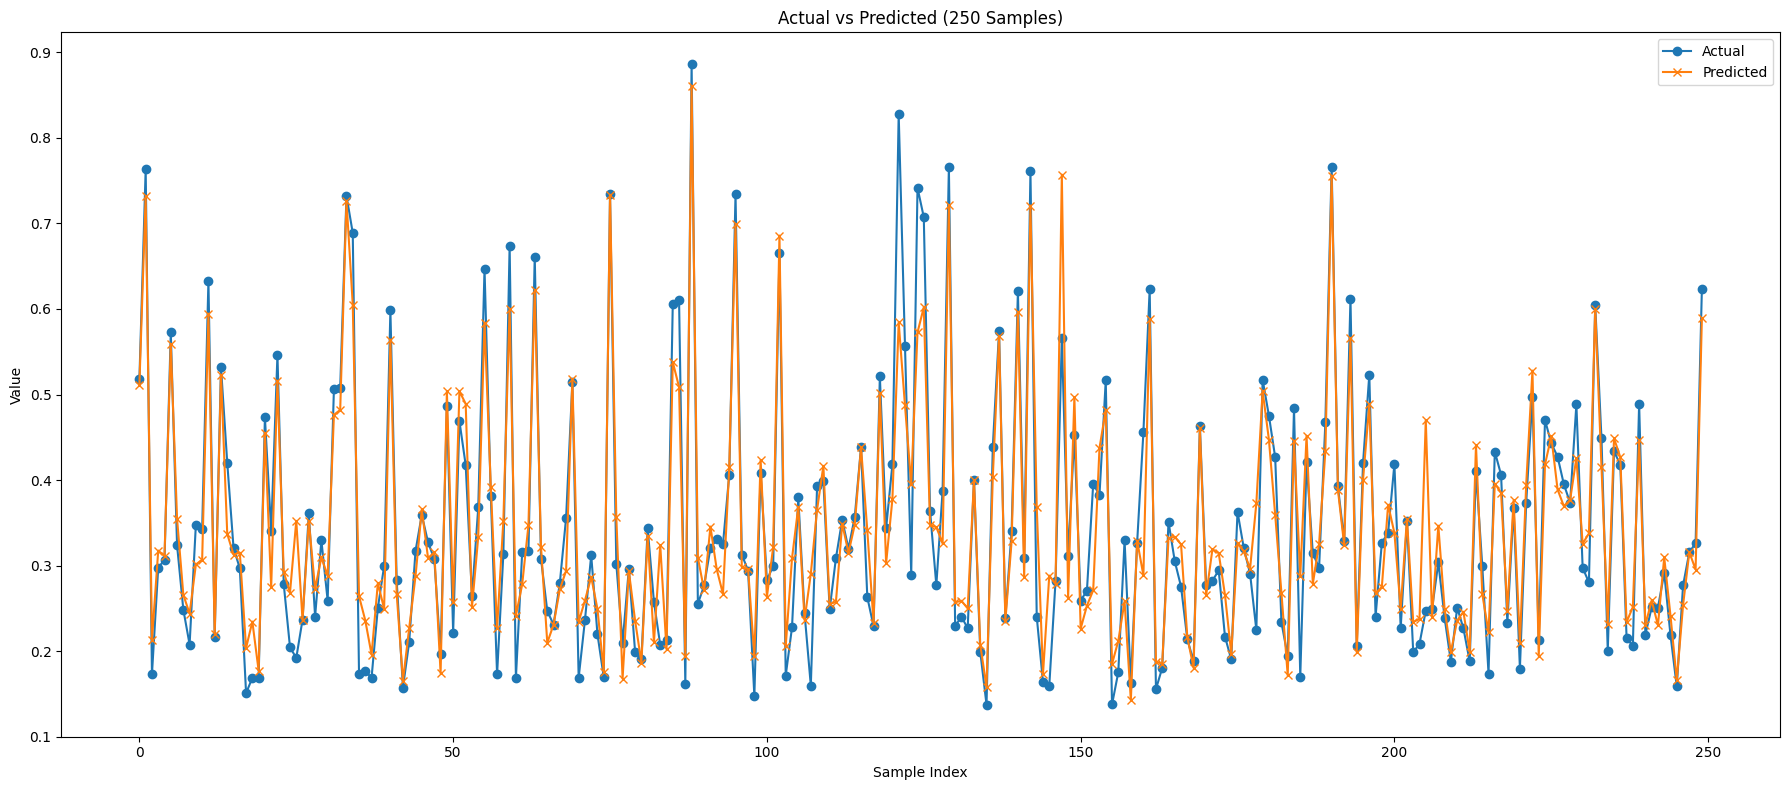

In [150]:
fig, axes = plt.subplots(1, 1, figsize=(18, 8))

sample_size = 250
sample_df = preds_df.sample(sample_size).reset_index(drop=True)
axes.plot(sample_df.index, sample_df["actual"], label="Actual", marker='o')
axes.plot(sample_df.index, sample_df["predicted"], label="Predicted", marker='x')
axes.set_title(f"Actual vs Predicted ({sample_size} Samples)")
axes.set_xlabel("Sample Index")
axes.set_ylabel("Value")
axes.legend()

plt.tight_layout()
plt.show()


In [ ]:
"""import joblib

joblib.dump({
    "model": model,
}, "popularity_model.pkl")
"""

['popularity_model.pkl']

In [154]:
df_model.head(10)

,week_number,year_number,week_sin,week_cos,season,bundle_type,usage_type,service_class_category,price,log_price,...,is_sms_only,is_combo_bundle,is_unlimited_bundle,is_speed_based_bundle,speed_mbps,name_has_social,name_has_roaming,popularity,bundle_id,bundle_name
0,1,2025,0.120537,0.992709,winter,BUNDLE_DATA,CHARGED,PREPAID,4000.0,8.294300,...,0,0,0,0,0.0,0.0,0.0,0.307323,37076,Forfait 1.6Go 30 jours@4000F
1,1,2025,0.120537,0.992709,winter,INT_BUNDLE_VOICE,CHARGED,PREPAID,690.0,6.538140,...,0,0,0,0,0.0,0.0,0.0,0.234772,50134,Forfait appels RCA 2 mins 30 jours@690F
2,1,2025,0.120537,0.992709,winter,INT_BUNDLE_VOICE,CHARGED,PREPAID,200.0,5.303305,...,0,0,0,0,0.0,0.0,0.0,0.155463,50129,Forfait appels Nigeria 2 mins 30 jours@200F
3,1,2025,0.120537,0.992709,winter,BUNDLE_DATA,CHARGED,PREPAID,215.0,5.375278,...,0,0,0,0,0.0,0.0,0.0,0.413100,35070,Forfait 1 jour 170MB@215F
4,1,2025,0.120537,0.992709,winter,BUNDLE_DATA,CHARGED,PREPAID,50050.0,10.820798,...,0,0,1,0,0.0,0.0,0.0,0.339628,36667,NDAKO BOX ILLIMITE@50050F
5,1,2025,0.120537,0.992709,winter,INT_BUNDLE_VOICE,CHARGED,PREPAID,1500.0,7.313887,...,0,0,0,0,0.0,0.0,0.0,0.327224,50191,Int Bundle ROW 10min 30jours a 1500F
6,1,2025,0.120537,0.992709,winter,INT_BUNDLE_VOICE,CHARGED,PREPAID,590.0,6.381816,...,0,0,0,0,0.0,0.0,0.0,0.352477,50214,Forfait appels Guinee Conakry 2 mins 30 jours@...
7,1,2025,0.120537,0.992709,winter,BUNDLE_VOICE,CHARGED,PREPAID,185.0,5.225747,...,0,0,0,0,0.0,0.0,0.0,0.738287,80069,Ndeko_11Mins 1 jour@185F
9,1,2025,0.120537,0.992709,winter,BUNDLE_DATA,CHARGED,PREPAID,50.0,3.931826,...,0,0,0,0,0.0,0.0,0.0,0.338694,36279,Promo Back2School 250MB 2 Days @50F
11,1,2025,0.120537,0.992709,winter,BUNDLE_DATA,CHARGED,PREPAID,425.0,6.054439,...,0,0,0,0,0.0,0.0,0.0,0.531439,36602,Maxinet 3 Days 9H@425F


### Casual Inference Model

Causal inference is the field of statistics and data science that tries to estimate the effect of an action, treatment, or intervention on an outcome.
    
* is the new products sales are incremental or cannibalistic,and which product’s sales are affected by a new product!

### Genetic Algorithm